<a href="https://colab.research.google.com/github/Computer-Cluster/Incremental-Learning/blob/main/optDigitNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from tensorflow.keras.utils import to_categorical, plot_model
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# Load and preprocess the Optdigits dataset
digits = load_digits()
images = digits.images
labels = digits.target

# Resize and normalize the images
images = images.reshape((images.shape[0], images.shape[1], images.shape[2], 1))
images = images.astype('float32') / 16.0

# Convert labels to one-hot encoding
labels = to_categorical(labels, num_classes=10)

# Split the dataset into training and testing
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

In [3]:
model = models.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Visualize the network architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
print("Diagrama de la arquitectura de la red guardado como 'model_architecture.png'")

Diagrama de la arquitectura de la red guardado como 'model_architecture.png'


In [5]:
#  Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
# Train the model
history = model.fit(train_images, train_labels, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2639 - loss: 2.2233 - val_accuracy: 0.5347 - val_loss: 1.7697
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6818 - loss: 1.5083 - val_accuracy: 0.8264 - val_loss: 0.8438
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8388 - loss: 0.7057 - val_accuracy: 0.8542 - val_loss: 0.5457
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8816 - loss: 0.4321 - val_accuracy: 0.8924 - val_loss: 0.4518
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.3225 - val_accuracy: 0.9097 - val_loss: 0.3702
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9434 - loss: 0.2376 - val_accuracy: 0.8924 - val_loss: 0.3561
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9159 - loss: 0.2627 - val_accuracy: 0.9028 - val_loss: 0.2951
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9523 - loss: 0.1863 - val_accuracy: 0.8854 - val_loss

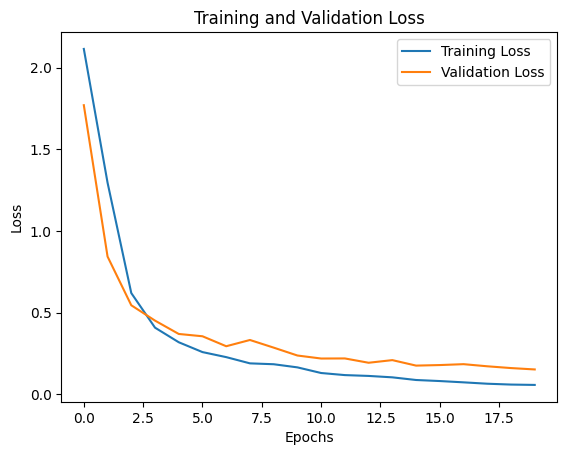

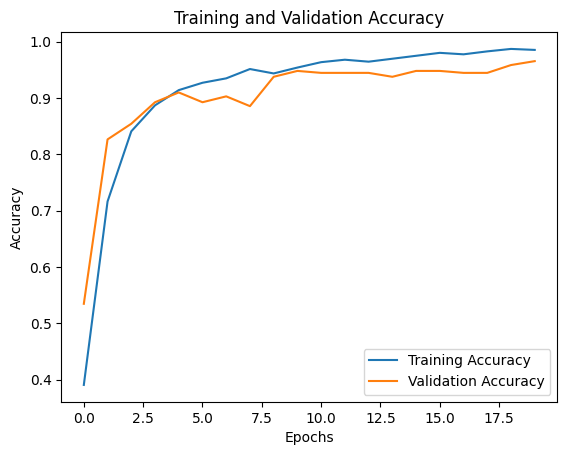

In [7]:
#  Plot loss and accuracy during training
history_dict = history.history

# Plotting the loss
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting accuracy
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Precisión en el conjunto de prueba: {test_acc:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9808 - loss: 0.0837  
Precisión en el conjunto de prueba: 0.9722


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Predicción: 6, Etiqueta real: 6


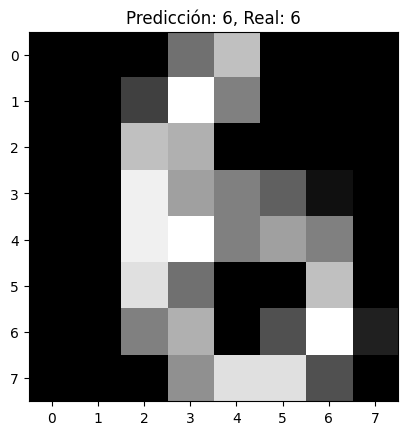

Predicción: 9, Etiqueta real: 9


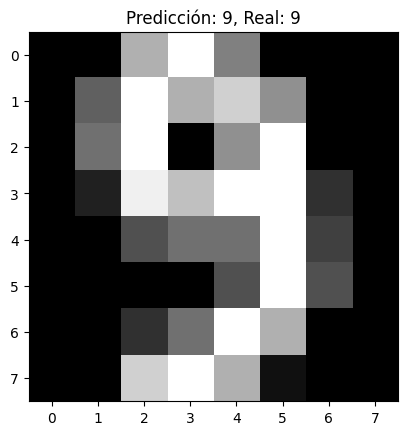

Predicción: 3, Etiqueta real: 3


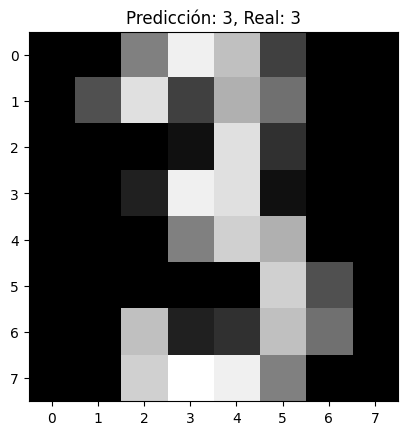

Predicción: 7, Etiqueta real: 7


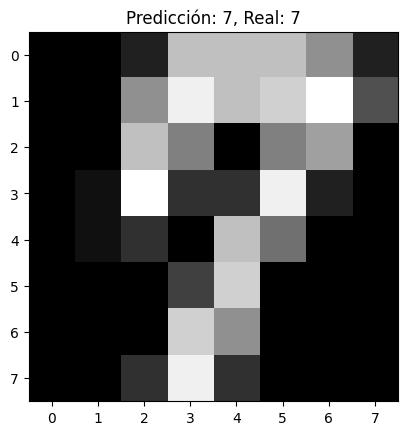

Predicción: 2, Etiqueta real: 2


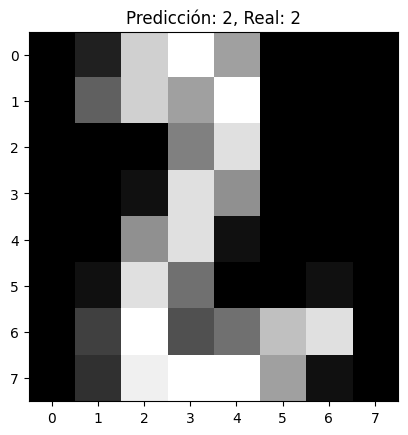

In [9]:
# Make predictions and visualize results
predictions = model.predict(test_images)


for i in range(5):
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(test_labels[i])
    print(f'Predicción: {predicted_label}, Etiqueta real: {true_label}')

    plt.imshow(test_images[i].reshape(8, 8), cmap='gray')
    plt.title(f'Predicción: {predicted_label}, Real: {true_label}')
    plt.show()

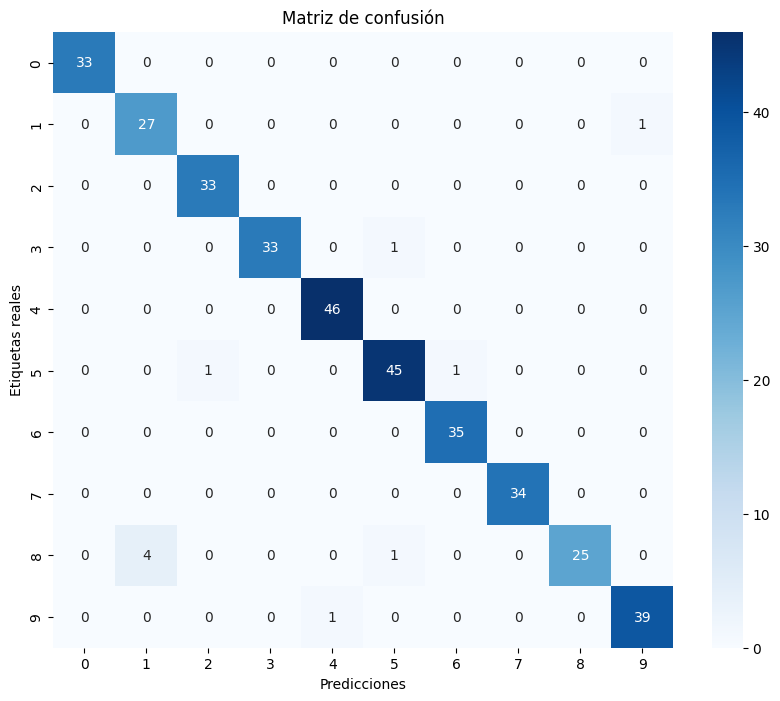

In [10]:
# Confusion matrix
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas reales')
plt.title('Matriz de confusión')
plt.show()